<a href="https://colab.research.google.com/github/ishwaryac20-prog/Python_DA_Assignment_Data_Visualization/blob/main/Python_DA_Assignment_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🚕 Python DA Assignment 2 – Data Visualization

### 📊 Taxi Trip Data Analysis using Pandas, Matplotlib & Seaborn

**Objective:** Clean, analyze, and visualize the Seaborn `taxis` dataset to understand patterns in fare, distance, tips, payment methods, boroughs, and pickup zones.

> This notebook follows the assignment requirements: data loading, missing-value handling, and 9 required visualizations.


## 1️⃣ Import Required Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully! ✅")


Libraries imported successfully! ✅


## 2️⃣ Load the Taxis Dataset 🚕

In [2]:

# Load the 'taxis' dataset as specified in the assignment
df = sns.load_dataset("taxis")

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (6433, 14)


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


### 🔎 Initial Dataset Inspection

In [3]:

print("Dataset Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe(include="all").T)


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
pickup,6433,NaN,NaN,NaN,2019-03-16 08:31:28.514223616,2019-02-28 23:29:03,2019-03-08 15:50:34,2019-03-15 21:46:58,2019-03-23 17:41:38,2019-03-31 23:43:45,NaN
dropoff,6433,NaN,NaN,NaN,2019-03-16 08:45:49.491217408,2019-02-28 23:32:35,2019-03-08 16:12:51,2019-03-15 22:06:44,2019-03-23 17:51:56,2019-04-01 00:13:58,NaN
passengers,6433.0,NaN,NaN,NaN,1.539251,0.0,1.0,1.0,2.0,6.0,1.203768
distance,6433.0,NaN,NaN,NaN,3.024617,0.0,0.98,1.64,3.21,36.7,3.827867
fare,6433.0,NaN,NaN,NaN,13.091073,1.0,6.5,9.5,15.0,150.0,11.551804
tip,6433.0,NaN,NaN,NaN,1.97922,0.0,0.0,1.7,2.8,33.2,2.44856
tolls,6433.0,NaN,NaN,NaN,0.325273,0.0,0.0,0.0,0.0,24.02,1.415267
total,6433.0,NaN,NaN,NaN,18.517794,1.3,10.8,14.16,20.3,174.82,13.81557
color,6433,2,yellow,5451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment,6389,2,credit card,4577,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## 3️⃣ Missing Value Analysis 🧹

The assignment requires us to:
- Check missing values.
- Identify columns containing missing data.
- Impute numerical and categorical values using appropriate strategies.
- Remove rows only where missing values cannot reasonably be imputed.


In [4]:

# Check missing values
missing_before = df.isna().sum().sort_values(ascending=False)

print("Missing values by column:")
display(missing_before.to_frame("Missing_Count"))

print("Columns containing missing values:")
display(missing_before[missing_before > 0])


Missing values by column:


,Missing_Count
dropoff_zone,45
dropoff_borough,45
payment,44
pickup_zone,26
pickup_borough,26
pickup,0
tip,0
fare,0
distance,0
passengers,0


Columns containing missing values:


,0
dropoff_zone,45
dropoff_borough,45
payment,44
pickup_zone,26
pickup_borough,26


### 🛠️ Handle Missing Values

In [5]:

# Work on a copy so the original dataset remains unchanged
df_clean = df.copy()

# Convert pickup to datetime before further analysis
df_clean["pickup"] = pd.to_datetime(df_clean["pickup"], errors="coerce")

# Numerical columns: median is used because it is less sensitive to outliers
numeric_cols = df_clean.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical/object columns: mode is used
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    if df_clean[col].isna().any():
        mode_value = df_clean[col].mode(dropna=True)
        if not mode_value.empty:
            df_clean[col] = df_clean[col].fillna(mode_value.iloc[0])

# Any remaining rows with missing pickup timestamps are removed because
# pickup is critical for the time-series visualization.
df_clean = df_clean.dropna(subset=["pickup"]).copy()

print("Missing values after cleaning:")
display(df_clean.isna().sum().sort_values(ascending=False).to_frame("Missing_Count"))

print(f"\nOriginal rows: {len(df):,}")
print(f"Cleaned rows : {len(df_clean):,}")
print("Cleaning completed successfully! ✅")


Missing values after cleaning:


,Missing_Count
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0



Original rows: 6,433
Cleaned rows : 6,433
Cleaning completed successfully! ✅


## 4️⃣ Basic Visualizations – Matplotlib / Pandas 📈

### 📈 4.1 Line Chart – Fare Over Time

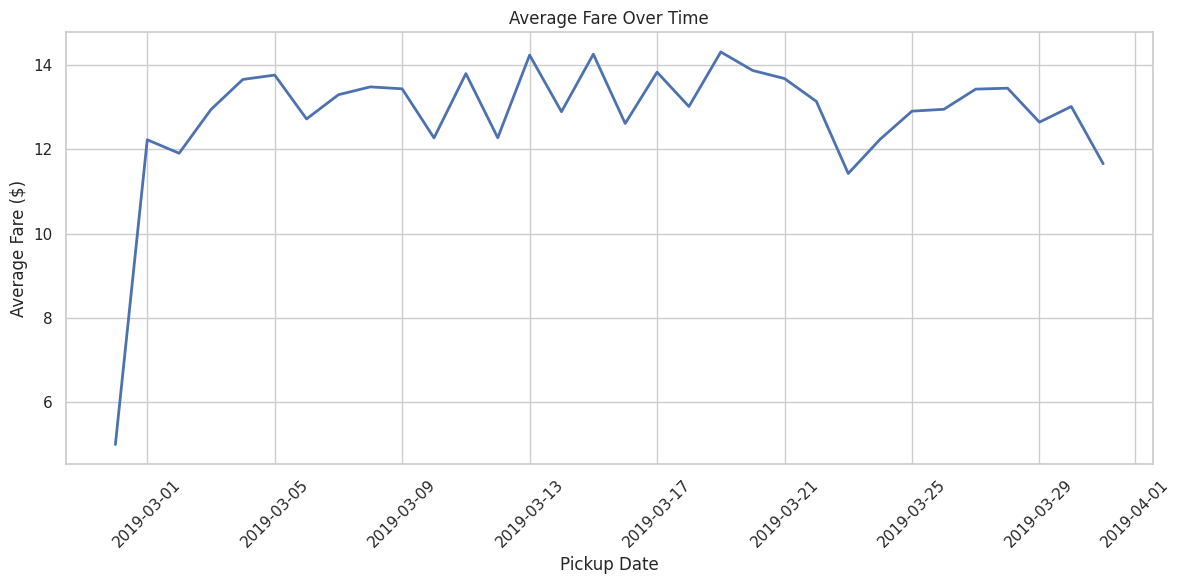

In [6]:

# Sort by pickup timestamp
time_df = df_clean.sort_values("pickup").copy()

# Aggregate to daily average fare for a clear time-series visualization
daily_fare = (
    time_df.set_index("pickup")["fare"]
    .resample("D")
    .mean()
    .dropna()
)

plt.figure(figsize=(12, 6))
plt.plot(daily_fare.index, daily_fare.values, linewidth=2)
plt.title("Average Fare Over Time")
plt.xlabel("Pickup Date")
plt.ylabel("Average Fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 📊 4.2 Bar Chart – Total Fare by Pickup Borough

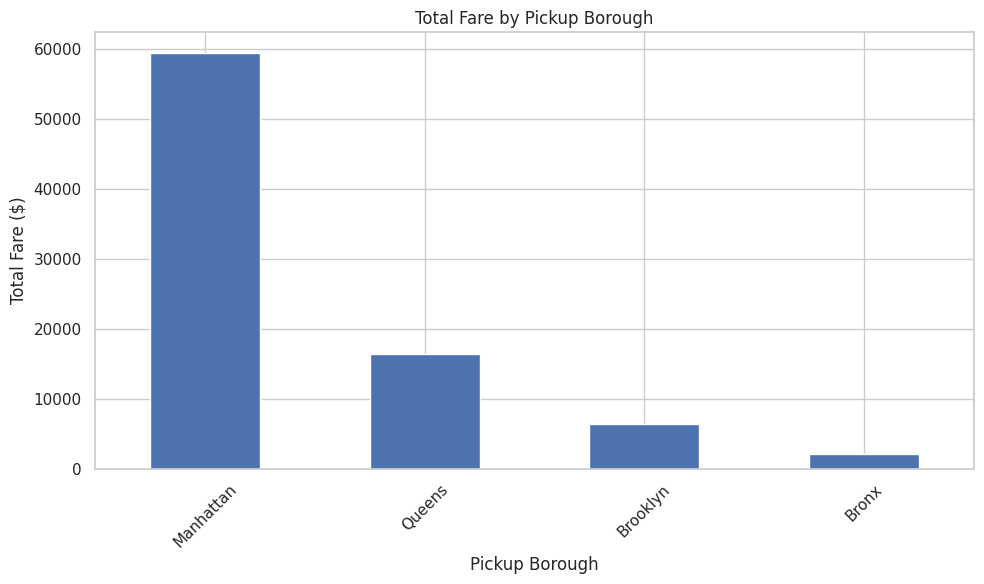

In [7]:

borough_fare = (
    df_clean.groupby("pickup_borough", observed=True)["fare"]
    .sum()
    .sort_values(ascending=False)
)

ax = borough_fare.plot(kind="bar", figsize=(10, 6))
ax.set_title("Total Fare by Pickup Borough")
ax.set_xlabel("Pickup Borough")
ax.set_ylabel("Total Fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 🥧 4.3 Pie Chart – Trips by Payment Method

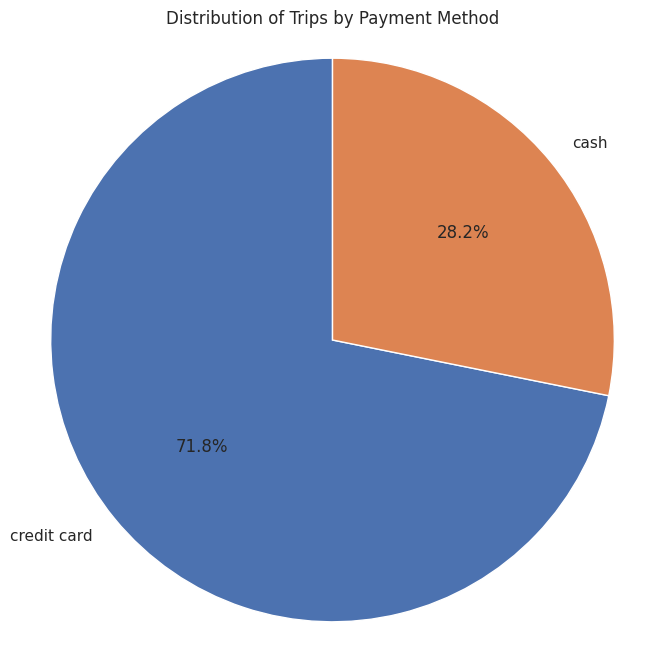

In [8]:

payment_counts = df_clean["payment"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Trips by Payment Method")
plt.axis("equal")
plt.show()


### 📏 4.4 Histogram – Distribution of Distance

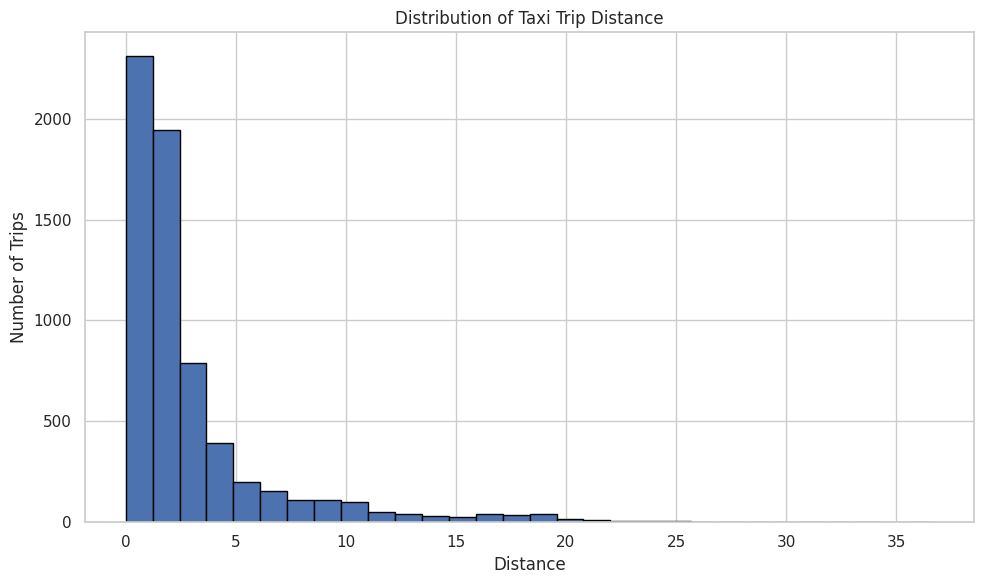

In [9]:

plt.figure(figsize=(10, 6))
plt.hist(df_clean["distance"], bins=30, edgecolor="black")
plt.title("Distribution of Taxi Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()


## 5️⃣ Statistical Plots – Seaborn 📦

### 📦 5.1 Box Plot – Tip Distribution by Pickup Borough

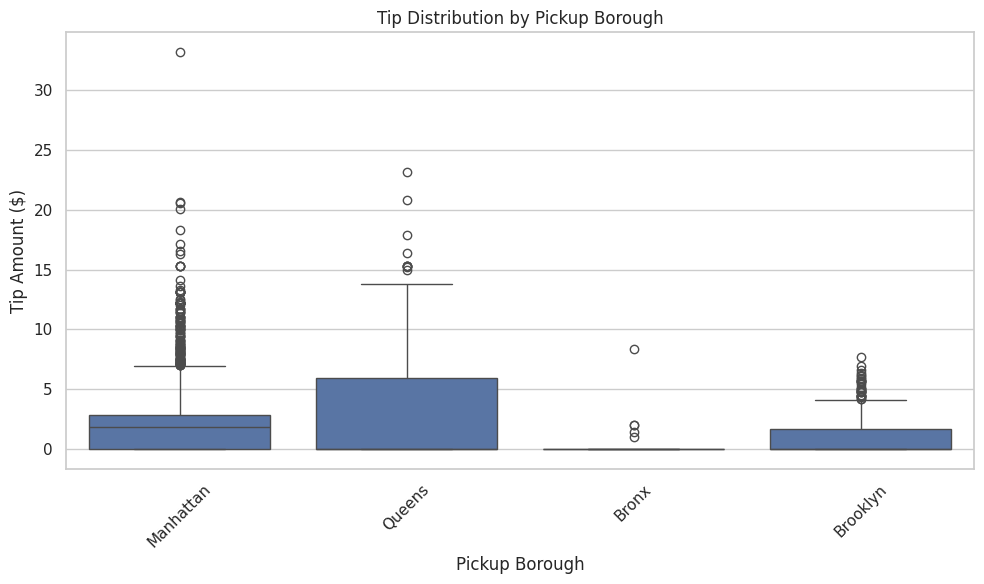

In [10]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x="pickup_borough", y="tip")
plt.title("Tip Distribution by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 🔢 5.2 Count Plot – Number of Trips by Pickup Borough

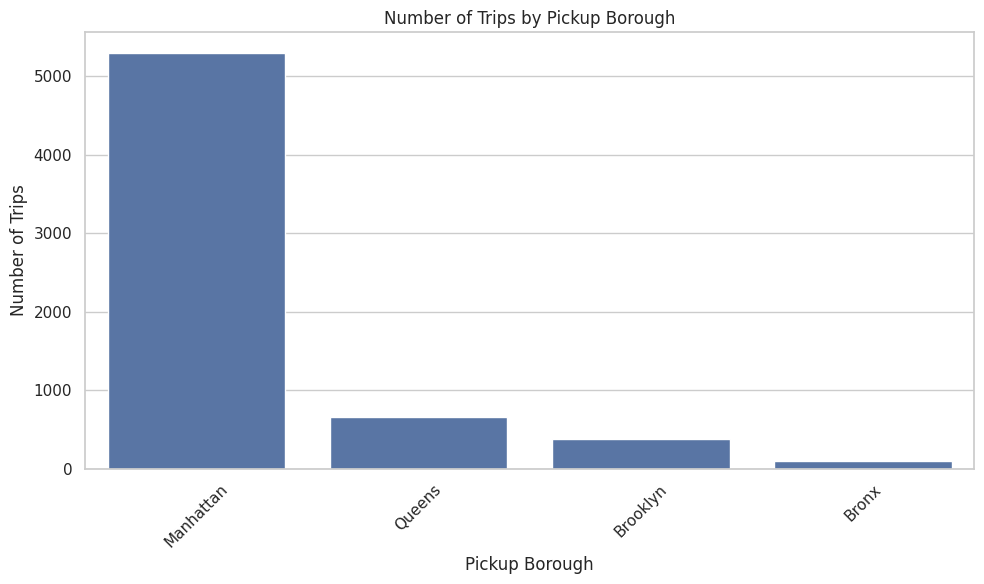

In [11]:

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x="pickup_borough", order=df_clean["pickup_borough"].value_counts().index)
plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 🔵 5.3 Scatter Plot – Distance vs Fare

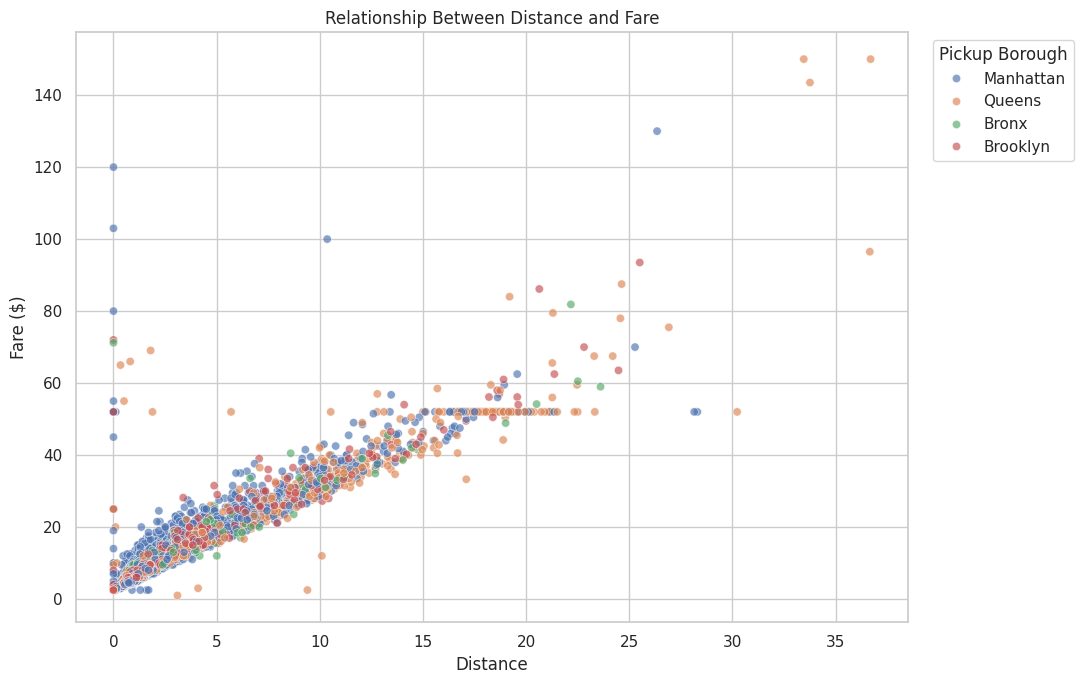

In [12]:

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_clean,
    x="distance",
    y="fare",
    hue="pickup_borough",
    alpha=0.65
)
plt.title("Relationship Between Distance and Fare")
plt.xlabel("Distance")
plt.ylabel("Fare ($)")
plt.legend(title="Pickup Borough", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 6️⃣ Advanced Visualizations 🔥

### 🔥 6.1 Heatmap – Correlation Between Numerical Variables

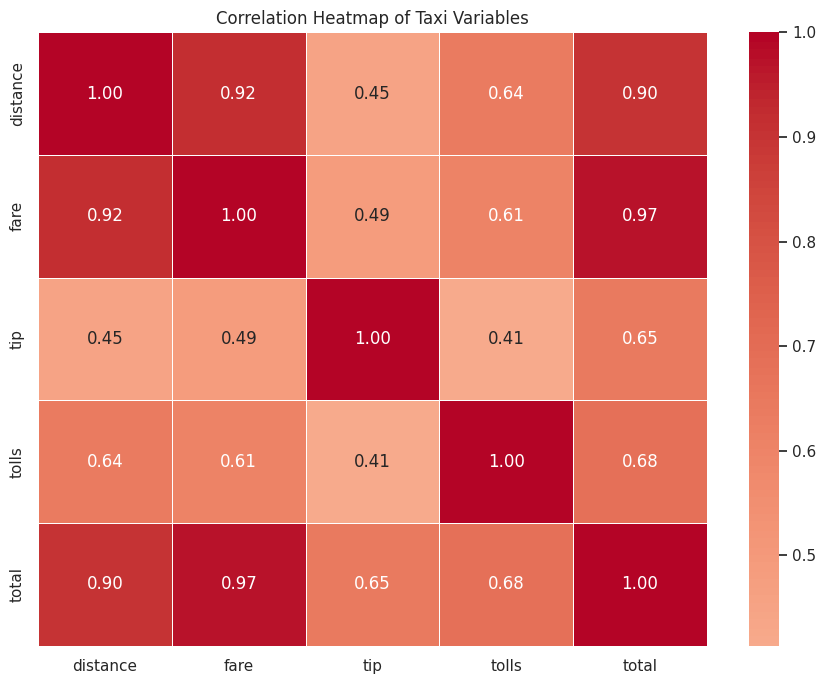

In [13]:

corr_cols = ["distance", "fare", "tip", "tolls", "total"]
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Taxi Variables")
plt.tight_layout()
plt.show()


### 🔗 6.2 Pair Plot – Distance, Fare, Tip and Total by Pickup Zone

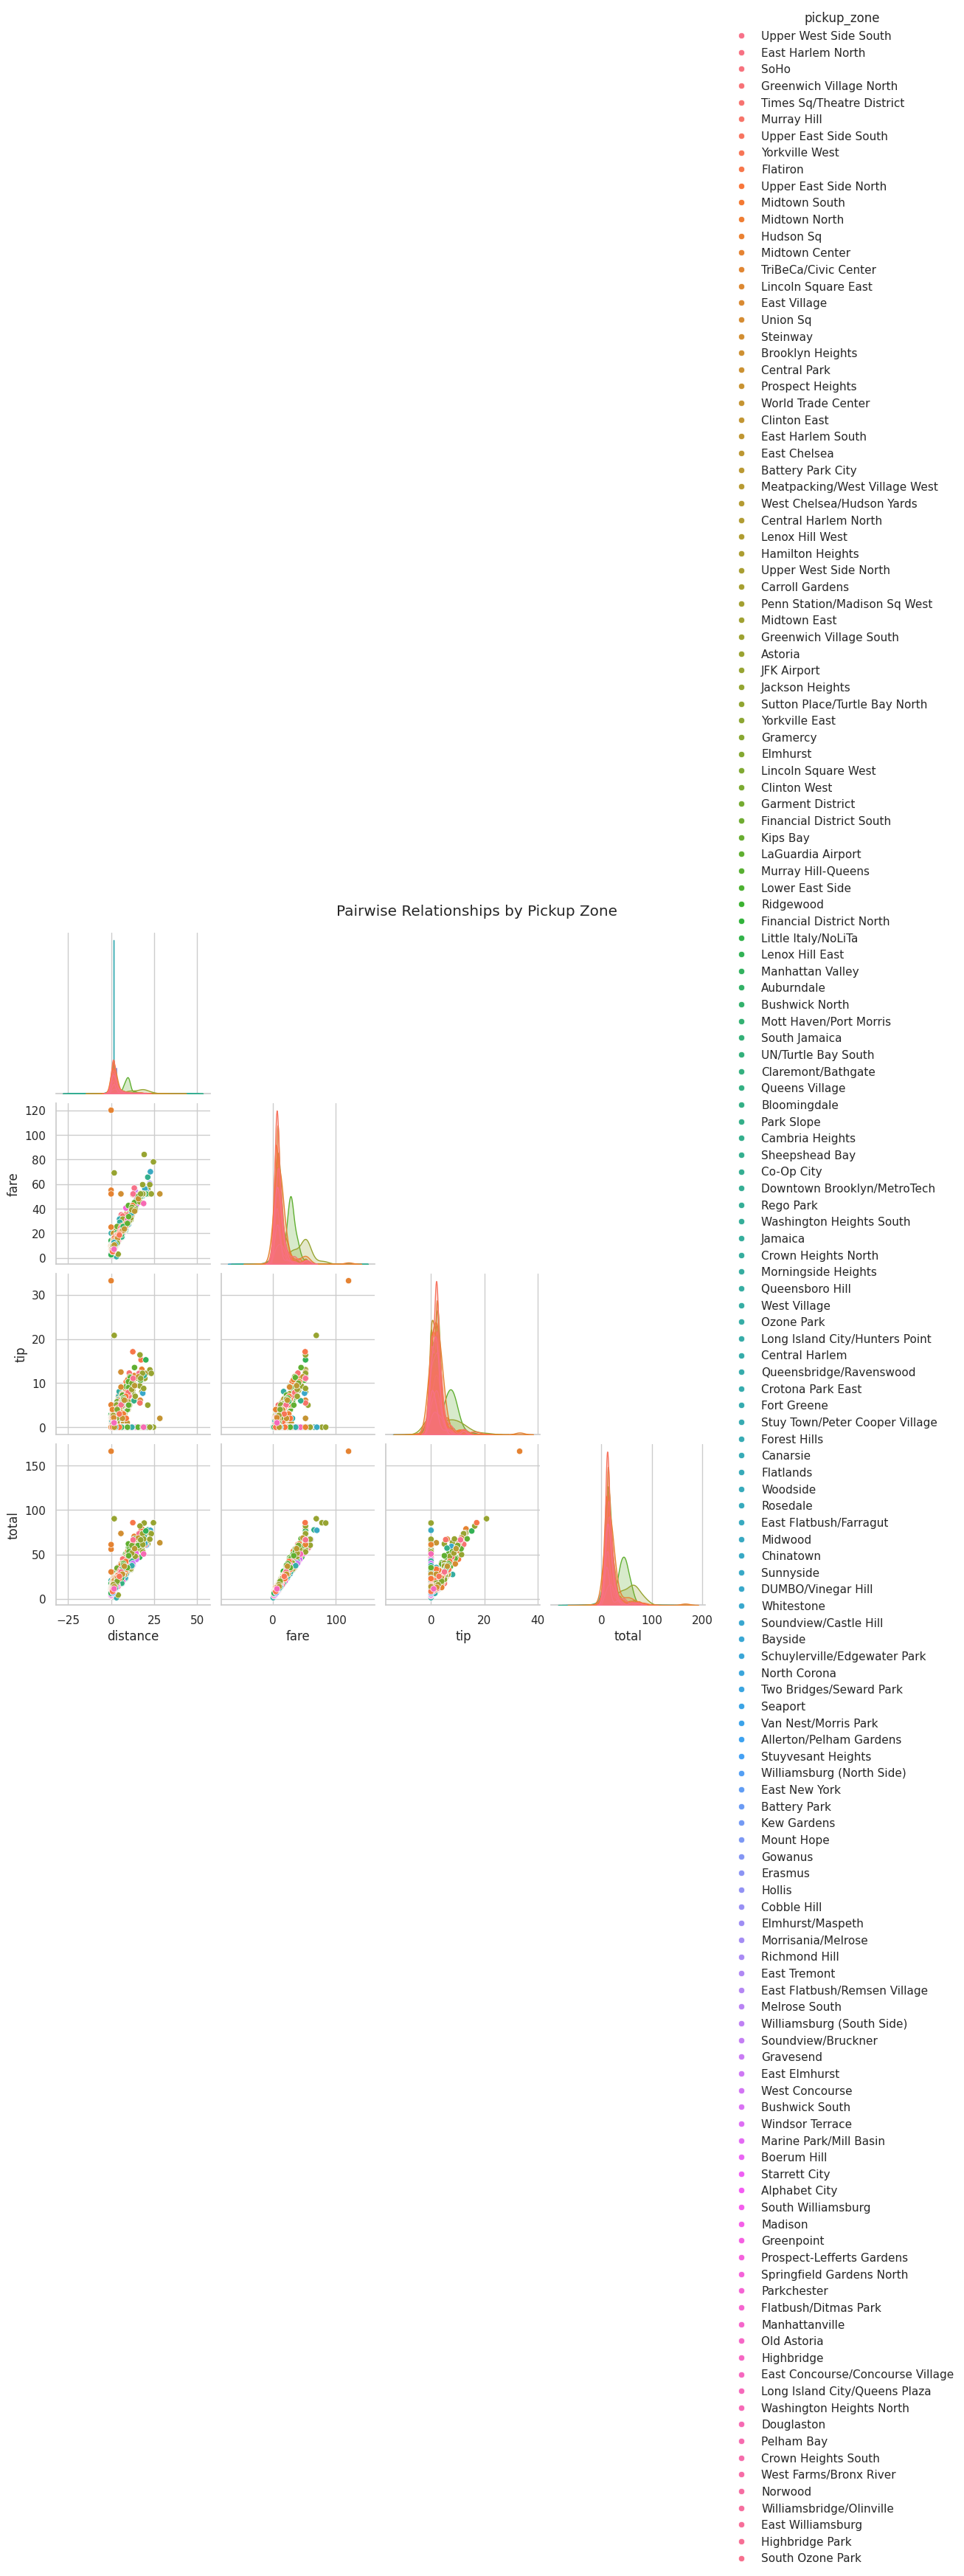

In [14]:

pair_cols = ["distance", "fare", "tip", "total", "pickup_zone"]

# Pair plots can become crowded with very large datasets,
# so a reproducible sample is used for readability.
pair_sample = df_clean[pair_cols].dropna()
if len(pair_sample) > 2000:
    pair_sample = pair_sample.sample(2000, random_state=42)

sns.pairplot(
    pair_sample,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone",
    corner=True
)
plt.suptitle("Pairwise Relationships by Pickup Zone", y=1.02)
plt.show()


### 🎻 6.3 Violin Plot – Fare Distribution by Payment Method

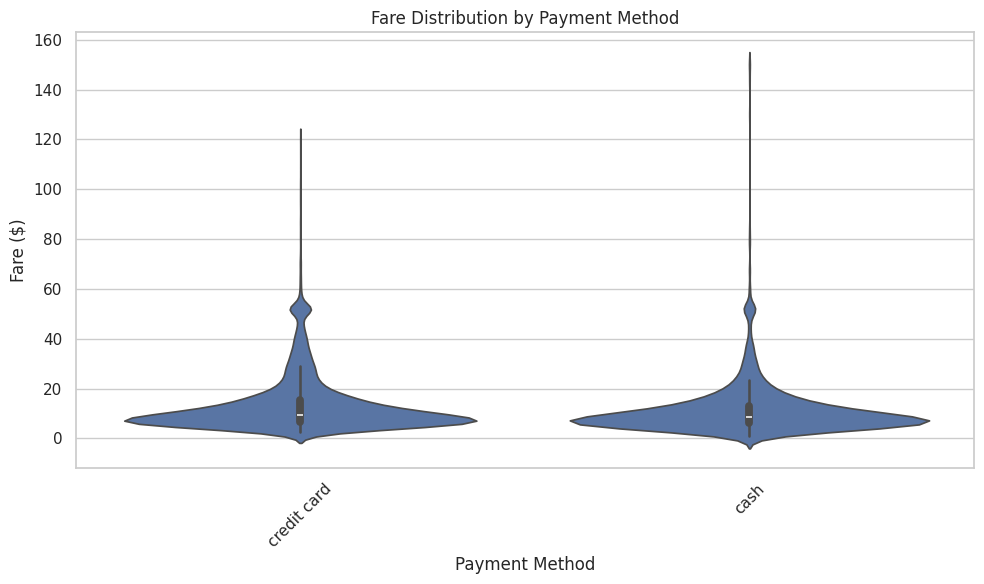

In [15]:

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_clean, x="payment", y="fare")
plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 7️⃣ Key Findings & Data Interpretation 📝

The following cells calculate concise findings directly from the cleaned dataset so that the summary is supported by the analysis.


In [16]:

# Automated summary statistics
top_borough = borough_fare.idxmax()
top_borough_fare = borough_fare.max()

most_common_payment = payment_counts.idxmax()
most_common_payment_pct = payment_counts.max() / payment_counts.sum() * 100

median_distance = df_clean["distance"].median()
median_fare = df_clean["fare"].median()

corr_distance_fare = df_clean[["distance", "fare"]].corr().loc["distance", "fare"]

print("📌 DATA VISUALIZATION SUMMARY")
print("-" * 55)
print(f"• Highest total fare comes from pickup borough: {top_borough}")
print(f"• Total fare for that borough: ${top_borough_fare:,.2f}")
print(f"• Most common payment method: {most_common_payment}")
print(f"• Share of trips using the most common payment method: {most_common_payment_pct:.1f}%")
print(f"• Median trip distance: {median_distance:.2f}")
print(f"• Median fare: ${median_fare:.2f}")
print(f"• Correlation between distance and fare: {corr_distance_fare:.2f}")


📌 DATA VISUALIZATION SUMMARY
-------------------------------------------------------
• Highest total fare comes from pickup borough: Manhattan
• Total fare for that borough: $59,426.42
• Most common payment method: credit card
• Share of trips using the most common payment method: 71.8%
• Median trip distance: 1.64
• Median fare: $9.50
• Correlation between distance and fare: 0.92



### 💡 Interpretation

- **Fare over time:** The line chart helps identify changes in average fare across pickup dates.
- **Borough contribution:** The bar chart highlights which pickup borough contributes the largest total fare.
- **Payment behavior:** The pie chart and violin plot show both the frequency and fare distribution associated with payment methods.
- **Trip distance:** The histogram shows the overall spread and concentration of trip distances.
- **Tips:** The box plot compares tip distributions across pickup boroughs and helps identify outliers.
- **Trip volume:** The count plot shows which boroughs have the highest number of recorded trips.
- **Distance vs fare:** The scatter plot and correlation value indicate the relationship between trip distance and fare.
- **Variable relationships:** The heatmap provides a compact view of correlations among distance, fare, tip, tolls, and total.
- **Pickup zones:** The pair plot allows comparison of multiple numerical relationships across pickup zones.



## 8️⃣ Final Conclusion 🎯

The taxi dataset was successfully loaded, inspected, cleaned, and visualized. Missing values were handled using median imputation for numerical fields and mode imputation for categorical fields, while rows with unusable pickup timestamps were removed.

The visualizations provide a complete exploratory view of:
**fare trends, borough-level revenue, payment behavior, trip distance, tips, trip volume, distance–fare relationships, numerical correlations, pickup-zone patterns, and fare distributions by payment method.**
